# 01 · The program is data

You will write the first two programs of a bring-up, a readout tone with an acquisition and then a pi pulse followed by a readout, and then take both of them apart.

Every builder call appends one typed node to a tree and sends nothing anywhere. The tree stays in memory, where you can read it, measure it, compare it, rewrite it, and write it to a file. Part 0 ran a program somebody else had written. This part is where you find out what one is made of, and Part 2 runs the ones you write yourself.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
import difflib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.operations import Play, Wait
from qprogram.waveforms import Arbitrary, FlatTop, Gaussian, IQDrag, IQPair, IQZero, Ramp, Square, SuddenNetZero

A circuit says `X(q0)`. An instrument needs an output port, a carrier frequency, an envelope shape, a duration, and an amplitude, and a gate carries none of them.

The dict below is the simulated chip the whole tutorial talks to. It is here so that the programs you build have real numbers to put on a bus, and every part from 2 onward measures one of them back.

In [3]:
# The simulated chip this tutorial calibrates. Every part writes down the numbers it uses, and
# every fit later has to recover them. Part 1 plays nothing into a model, so it reads five.
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, qubit 0 transition frequency at the flux sweet spot
    "q0_fr": 7.20e9,  # Hz, readout resonator
    "q0_a_pi": 0.62,  # drive amplitude of a pi pulse (DAC units)
    "q1_f01": 5.12e9,
    "q1_a_pi": 0.55,
}

print("qubit 0 drive:  ", DEVICE["q0_f01"] / 1e9, "GHz")
print("qubit 0 readout:", DEVICE["q0_fr"] / 1e9, "GHz")
print("pi amplitude:   ", DEVICE["q0_a_pi"], "(DAC units)")

qubit 0 drive:   4.85 GHz
qubit 0 readout: 7.2 GHz
pi amplitude:    0.62 (DAC units)


## 1.1 Buses and schemas

The simplest spelling of a bus is a plain string, and a program written that way is complete and will run.

In [4]:
raw = qp.QProgram(label="readout_raw_strings")
raw.set_frequency("readout_q0", DEVICE["q0_fr"])
m_raw0 = raw.measure("readout_q0", "readout", "weights")
m_raw1 = raw.measure("readout_q0", "readout", "weights")

print(qp.dumps(raw))
print("buses:  ", sorted(raw.buses))
print("schema: ", raw.schema, "<- nothing declared, so nothing is checked")
print("handles:", m_raw0.name, m_raw1.name)  # one global counter, since a string has no bus to prefix

#!QProgram 1.0

metadata:
  label: "readout_raw_strings"

body:
  set_frequency "readout_q0" 7200000000.0
  measure "readout_q0" "readout" "weights" name="m0"
  measure "readout_q0" "readout" "weights" name="m1"

buses:   ['readout_q0']
schema:  None <- nothing declared, so nothing is checked
handles: m0 m1


Nothing checked those bus names. Misspell one as `"raedout_q0"` and the program still builds, still serializes, and finds you out on hardware.

`BusSchema` closes that gap without changing what lands in the tree. A schema declares which kinds of bus each element of the chip has, and it declares nothing about how many qubits exist, so any index resolves. What it hands back is a `BusRef`, a real `str` subclass carrying six fields of metadata, and everywhere QProgram wants a bus name a `BusRef` works. The index field is spelled `idx` rather than `index` because a `str` subclass must not shadow `str.index`.

The quoted `"readout"` and `"weights"` in the program above are pulse names rather than bus names, and section 1.3 is where they get their numbers.

In [5]:
schema = BusSchema.transmon()  # each qubit: drive (IQ), readout (IQ, with an ADC)
q = schema.q

readout_bus = q[0].readout
print("schema:      ", schema)
print("the ref:     ", repr(readout_bus), "| a str?", isinstance(readout_bus, str))
print("element/idx: ", readout_bus.element, readout_bus.idx)
print("kind:        ", readout_bus.kind)
print("channel:     ", readout_bus.channel, "| acquires:", readout_bus.acquires)
print("its schema:  ", readout_bus.schema is schema)
print("any index:   ", q[7].drive, q[7].drive.channel)

schema:       BusSchema(q(drive: ('IQ', False), readout: ('IQ', True)))
the ref:      'q0/readout' | a str? True
element/idx:  q 0
kind:         readout
channel:      IQ | acquires: True
its schema:   True
any index:    q7/drive IQ


### What the schema catches

`channel` records how many DACs feed the line and `acquires` records whether an ADC listens to it. Both are facts about copper, and QProgram turns both into errors raised on the line that made the mistake rather than on hardware an hour later.

Three checks run. An IQ bus needs an IQ waveform and a single-channel bus needs a real-valued one, which `measure` applies twice over, once to the pulse and once to the weights. `measure` needs a bus with an ADC. And a program carries at most one schema, so a reference built from a second one is refused even though the two schemas describe the same chip, because the checking is done by the reference and not by the string it happens to spell.

All three raise `qp.ValidationError`, naming the bus, the reason, and what to do instead. The first of them runs a second time in section 1.3, when `with_waveforms` puts a real envelope where a name used to be.

In [6]:
scratch = qp.QProgram(label="deliberate_mistakes", schema=schema)

try:
    scratch.play(q[0].drive, Square(amplitude=0.5, duration=40))
except qp.ValidationError as exc:
    print("channel mismatch ->", exc)

try:
    scratch.measure(q[0].drive, "readout", "weights")
except qp.ValidationError as exc:
    print("\nno ADC          ->", exc)

try:
    scratch.play(BusSchema.transmon().q[0].drive, "pi")  # the same shape, a different schema object
except qp.ValidationError as exc:
    print("\nforeign schema  ->", exc)

channel mismatch -> Bus 'q0/drive' is an IQ channel but received a single-channel Waveform (Square). Use an IQWaveform (e.g. IQPair, IQDrag) instead.

no ADC          -> Bus 'q0/drive' does not support acquisition (acquires=False). measure() can only be called on buses with an ADC (e.g. readout buses).

foreign schema  -> BusRef 'q0/drive' (element='q', kind='drive') comes from a different BusSchema than the one attached to this QProgram. A program may use only one schema; use a plain string bus name if you need to reference a bus that lives outside the schema.


The two spellings mix. A program can be mostly schema-backed with one odd bus slotted in by name, and you lose the checks for that bus and keep them everywhere else.

## 1.2 Operations

Naming a line is half the vocabulary. The verbs are the other half, and each call appends exactly one typed node to whichever block is open and returns `None`. Two are exceptions. `measure` hands back a `MeasurementHandle` and `get_parameter` hands back a `Variable`.

Durations are nanoseconds, frequencies hertz, phases radians, and gain and offset are dimensionless. Every numeric argument also accepts a variable or an expression built from one, and that is Part 2.

| Call | Node it appends | First shown in |
|---|---|---|
| `play(bus, waveform)` | `Play` | here |
| `measure(bus, waveform, weights, *, name=None, fields=(MF.IQ,))` | `Measure` | here |
| `wait(bus, duration)` | `Wait` | here |
| `sync(buses=None)` | `Sync` | here |
| `set_frequency(bus, frequency)` | `SetFrequency` | here |
| `set_gain(bus, gain)` | `SetGain` | here |
| `set_phase(bus, phase)`, `reset_phase(bus)` | `SetPhase`, `ResetPhase` | here |
| `set_parameter(bus, parameter, value)`, `get_parameter(bus, parameter)` | `SetParameter`, `GetParameter` | Part 2 |
| `set_offset(bus, offset_path0, offset_path1=None)` | `SetOffset` | Part 3 |
| `call(fragment, *args, **kwargs)` | `Call` | Part 4 |

QProgram did not invent that vocabulary. It is roughly the intersection of what commercial sequencers offer, given portable names, and Part 6 adds to it through a vendor namespace rather than a patch to the core.

In [7]:
sketch = qp.QProgram(label="one_node", schema=schema)
sketch.play(q[0].drive, "pi")  # returns None; the program grew by one node

node = sketch.body.elements[0]
print("class:  ", type(node).__name__)
print("bus:    ", node.bus)
print("payload:", node.waveform)
print("buses():", node.buses())

class:   Play
bus:     q0/drive
payload: pi
buses(): {'q0/drive'}


### The first readout pulse

The smallest useful program on a new chip is one readout tone plus one acquisition. `measure(bus, waveform, weights)` outputs the pulse itself, so there is no separate `play` on the readout line, and `name=` and `fields=` after it are keyword-only.

The weights are the second waveform, a window that multiplies the ADC stream before it is summed into the single point you get back. A flat window of ones is the honest starting default and the one this tutorial uses throughout.

Both arguments are `IQPair`s because a readout line is two paths. When the quadrature is silent, `IQZero(Square(amplitude=0.2, duration=2000))` names the same pulse in one constructor, and it is the one to reach for when a calibrated single-channel envelope has to go down an IQ line. The tone is flat and 2000 ns long because the resonator fills in roughly 106 ns and the integration has to run well past that.

In [8]:
readout_pulse = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
weights = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))

readout_program = qp.QProgram(
    label="first_readout",
    description="One 2 us readout tone on qubit 0, integrated into one IQ point.",
    schema=schema,
)
readout_program.set_frequency(q[0].readout, DEVICE["q0_fr"])
m0 = readout_program.measure(q[0].readout, readout_pulse, weights, fields=(MF.IQ, MF.STATE))

print(qp.dumps(readout_program))

#!QProgram 1.0

metadata:
  label: "first_readout"
  description: "One 2 us readout tone on qubit 0, integrated into one IQ point."

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  set_frequency q[0].readout 7200000000.0
  measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state", "iq"]



### What a measurement asks for

`fields=` says which of a measurement's outputs you want back. `MF.IQ` is the integrated complex point and the default, `MF.STATE` is the platform's classification of that point into a 0 or a 1, and `MF.RAW` is the ADC trace the other two are computed from, which Part 4 reaches for.

The names are checked at the call rather than at run time, and the tuple stored on the node comes back in a canonical order rather than the order you asked in. A vendor extension registers its own field names through the seam Part 6 uses.

In [9]:
print("every field a core measurement can ask for:", [field.value for field in MF])
print("this measurement requested:                ", readout_program.body.elements[-1].fields)

try:
    readout_program.measure(q[0].readout, readout_pulse, weights, fields=("iq", "bogus"))
except qp.ValidationError as exc:
    print("\nchecked at the call:", exc)

every field a core measurement can ask for: ['state', 'iq', 'raw']
this measurement requested:                 ('state', 'iq')

checked at the call: unknown measurement field(s) ['bogus']. Known fields: ['iq', 'raw', 'state']. A vendor extension adds its own by registering `measure.fields.<name>` via qprogram.protocol.register_capability_tokens.


### The measurement handle

`measure` returns a `MeasurementHandle`, and a handle is a name and nothing more. The name is how you ask for this measurement's data after the run (`result.get(m0)` in Part 2), and the same object carries the state proxy a conditional reads in Part 4.

Names are allocated per bus for a `BusRef` and from one global counter for a raw string, which is the difference between `q0/readout/m0` here and the bare `m0` and `m1` in section 1.1. Pass `name=` to choose one yourself, and a name already taken is refused. Handles compare by name, so one you rebuild after loading a file still refers to the same measurement.

In [10]:
print("handle name:  ", m0.name)
print("rebuilt equal:", m0 == qp.MeasurementHandle("q0/readout/m0"))
print("all handles:  ", [handle.name for handle in readout_program.measurement_handles()])

try:
    readout_program.measure(q[0].readout, readout_pulse, weights, name="q0/readout/m0")
except qp.ValidationError as exc:
    print("\nduplicate name:", exc)

handle name:   q0/readout/m0
rebuilt equal: True
all handles:   ['q0/readout/m0']

duplicate name: measurement name 'q0/readout/m0' is already used by another measurement in this program


### The drive sequence

Now the other half of a bring-up, putting energy into the qubit and then reading it. This one uses most of the verbs you will need all day.

- `set_frequency(bus, hz)` and `set_gain(bus, g)` write hardware registers. Gain scales the whole output path, and the `amplitude` inside a waveform shapes the envelope. Two different knobs.
- `reset_phase(bus)` zeroes the oscillator phase on a bus and `set_phase(bus, radians)` writes it to a value you choose. Resetting before a sequence makes every shot start from the same reference, so the phase the qubit accumulates is the phase you asked for.
- `play(bus, waveform)` outputs one envelope and `wait(bus, ns)` idles one bus. Instructions land on a clock grid, 4 ns on a typical box, and QProgram rounds nothing onto it. A 3 ns wait reaches the platform as a 3, and the platform is where it is accepted or refused.
- `with program.block():` opens a plain container and changes nothing about what the statements inside it mean. It is the plainest member of a family. `average` and `sweep` in Part 2 and `if_` in Part 4 push a block onto the same stack.

### The sync barrier

Every bus keeps its own cursor, advanced only by the pulses and waits written to that bus, so two buses that have played different amounts have drifted apart by exactly the difference. A circuit has one global clock and a pulse program does not, and this operation exists for that reason.

`sync(buses)` holds every listed bus until the furthest-ahead one has finished. `sync()` with no argument covers every bus in the program, convenient here and expensive in Part 5, and `sync([])` raises rather than guess. The node stores its argument under `targets`, and a bare `sync()` stores `None` and reports no buses of its own, so it writes as a single unqualified line in the exercise below.

The 4 ns wait before the barrier is dead time, one clock cycle held open between the end of the drive and the start of the readout.

In [11]:
pi_pulse = IQDrag(amplitude=DEVICE["q0_a_pi"], duration=40, sigma=10, beta=0.15)

drive_program = qp.QProgram(
    label="drive_then_read",
    description="A calibrated pi pulse on qubit 0, then a readout.",
    schema=schema,
)
with drive_program.block():  # the preparation, as one group
    drive_program.set_frequency(q[0].drive, DEVICE["q0_f01"])
    drive_program.set_gain(q[0].drive, 1.0)
    drive_program.reset_phase(q[0].drive)  # every shot starts from the same phase reference
    drive_program.play(q[0].drive, pi_pulse)
    drive_program.wait(q[0].drive, 4)  # ns of dead time before the readout
drive_program.sync([q[0].drive, q[0].readout])
m_drive = drive_program.measure(q[0].readout, readout_pulse, weights, fields=(MF.IQ, MF.STATE))

print(qp.dumps(drive_program))

#!QProgram 1.0

metadata:
  label: "drive_then_read"
  description: "A calibrated pi pulse on qubit 0, then a readout."

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  block:
    set_frequency q[0].drive 4850000000.0
    set_gain q[0].drive 1.0
    reset_phase q[0].drive
    play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
    wait q[0].drive 4
  sync q[0].drive q[0].readout
  measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state", "iq"]



## 1.3 Waveforms are data

Both programs above played an envelope without ever saying what an envelope is. A waveform is a pure-data description of one. It knows nothing about hardware, and it can be built, measured, compared, and drawn with no program around it.

Two methods are the whole contract. `envelope(resolution=1)` returns the samples as a numpy array and `get_duration()` returns nanoseconds, and an IQ shape supplies `get_I()`, `get_Q()`, and `get_duration()` instead. Everything else is derived on the base class, so `area()`, `peak_amplitude()`, `rms_amplitude()`, `spectrum()`, and `plot()` answer for any shape, including one you write yourself in Part 6.

In [12]:
drive_envelope = Gaussian(amplitude=0.5, duration=40, sigma=8)

print("duration:", drive_envelope.get_duration(), "ns | samples:", drive_envelope.envelope().shape)
print("peak:    ", round(drive_envelope.peak_amplitude(), 4))
print("area:    ", round(drive_envelope.area(), 4), "ns of amplitude")
print("rms:     ", round(drive_envelope.rms_amplitude(), 4))
freqs, _ = drive_envelope.spectrum()
print("spectrum:", len(freqs), "bins out to", freqs[-1] / 1e6, "MHz")

duration: 40 ns | samples: (40,)
peak:     0.499
area:     9.8769 ns of amplitude
rms:      0.2976
spectrum: 21 bins out to 500.0 MHz


### Reading a shape

Four facts about those parameters, each of which has cost somebody an afternoon.

- `sigma` and `smooth_duration` are real widths in nanoseconds, not fractions of `duration`.
- `duration` is only the window the shape is sampled over, and an even-length window puts no sample on the centre, so a peak asked for at 0.5 is sampled at 0.499.
- `area()` integrates trapezoidally, so a 100 ns square at amplitude 0.5 comes to 49.5 rather than 50.
- `FlatTop`'s `buffer` pads outside `duration`, so it lengthens the shape rather than eating into the flat top.

Twelve single-channel shapes and five IQ shapes ship, and Part 6 adds one of its own. Two waveforms also add, and `a + b` concatenates them into a `Chained`.

In [13]:
print("sigma in ns:      ", Gaussian(amplitude=0.5, duration=40, sigma=8).sigma)
print("sampled peak:     ", round(Gaussian(amplitude=0.5, duration=40, sigma=8).peak_amplitude(), 4))
print("trapezoidal area: ", Square(amplitude=0.5, duration=100).area())
print("buffer pads out:  ", FlatTop(amplitude=0.5, duration=200, smooth_duration=20, buffer=10).get_duration(), "ns")

chained = Square(amplitude=0.2, duration=10) + Square(amplitude=0.1, duration=10)
print("a + b:            ", type(chained).__name__, "|", chained.get_duration(), "ns")

sigma in ns:       8
sampled peak:      0.499
trapezoidal area:  49.5
buffer pads out:   220 ns
a + b:             Chained | 20 ns


### Drawing a shape

The shortest spelling draws nothing at all. A bare waveform on the last line of a notebook cell renders its own envelope through `_repr_html_`, in a light and a dark version so the picture survives either notebook theme.

In [14]:
drive_envelope

`plot()` draws the same envelope.

<Axes: title={'left': 'Gaussian'}, xlabel='Time (ns)', ylabel='Amplitude'>

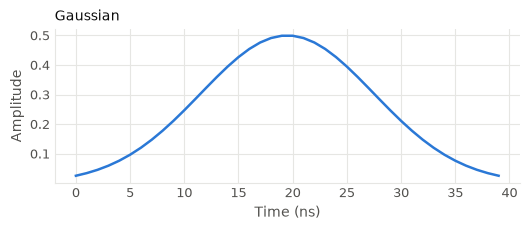

In [15]:
drive_envelope.plot()

Two things came back from that one call. The figure, titled with the class name and labelled in nanoseconds, and the matplotlib `Axes` it was drawn on. In a notebook the axes is also the cell's value, printed as `<Axes: ...>` beside the picture, so bind it or end the line with a semicolon.

Handing the axes back is the point. The call draws the data and gets out of the way, so a fuller title, a reference line, an annotation, or a fit is one ordinary method call on the object that came back. Part 2 hands you a result's axes the same way, and every figure in this tutorial is built like this.

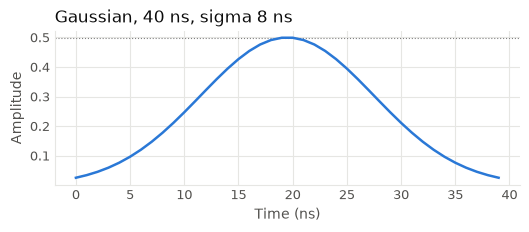

In [16]:
ax = drive_envelope.plot()
ax.set_title(f"Gaussian, {drive_envelope.get_duration()} ns, sigma {drive_envelope.sigma} ns", loc="left")
ax.axhline(drive_envelope.peak_amplitude(), color="grey", linestyle=":", linewidth=0.8)
plt.show()

### A row of panels

`target=` runs the other direction. You open the layout yourself and hand each panel to a waveform, and that is how six shapes fit in one row below. Part 4 passes the same argument to `result.plot` to put two clouds of single shots on one axes.

Nothing in a waveform says which line it belongs on. A `Ramp` is an envelope and only that, and the bus you send it down decides what it means. `BusSchema.transmon()` has no flux bus at all, and Part 3 reaches for `BusSchema.flux_tunable_transmon()` when it starts tuning the qubit with flux.

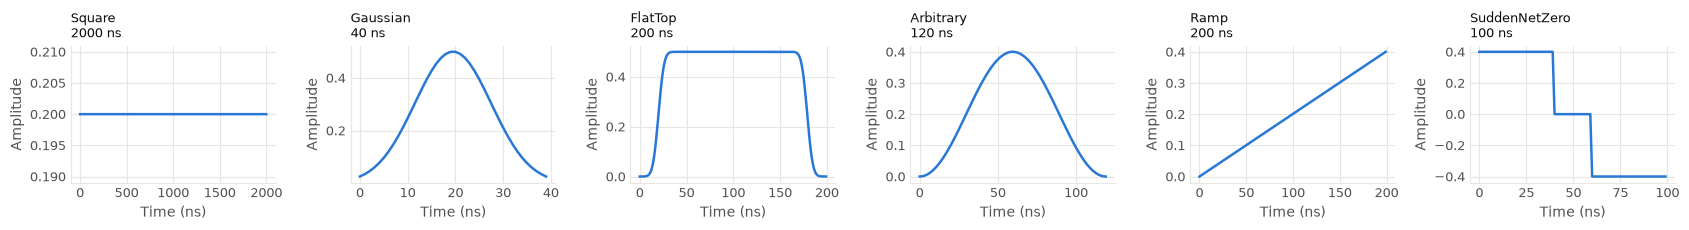

In [17]:
gallery = [
    Square(amplitude=0.2, duration=2000),  # the readout tone
    Gaussian(amplitude=0.5, duration=40, sigma=8),  # a short drive envelope
    FlatTop(amplitude=0.5, duration=200, smooth_duration=20),  # rise, hold, fall
    Arbitrary(0.4 * np.hanning(120)),  # samples you brought yourself, from optimal control or a fit
    Ramp(from_amplitude=0.0, to_amplitude=0.4, duration=200),  # a flux excursion
    SuddenNetZero(amplitude=0.4, duration=100, b=1.0, t_phi=20),  # a two-qubit gate pulse
]

fig, panels = plt.subplots(1, len(gallery), figsize=(17, 2.4))
for panel, waveform in zip(panels, gallery, strict=True):
    waveform.plot(target=panel)  # the waveform draws itself onto the panel we opened for it
    # plot() titles the panel with the class name; add the duration to it.
    panel.set_title(f"{type(waveform).__name__}\n{waveform.get_duration()} ns", loc="left", fontsize=9)
fig.tight_layout()
plt.show()

### IQ waveforms

A drive line is a pair of paths fed through an IQ mixer, so it takes an `IQWaveform`. `get_I()` and `get_Q()` hand back the two halves as ordinary single-channel waveforms, and for an `IQDrag` they come back as a `Gaussian` and a `GaussianDragCorrection`, shapes you could have built yourself.

`plot()` on an IQ shape returns the two panels as an `(I, Q)` pair, and `target=` wants a pair too. The panels carry their own vertical scales, and that is what keeps the Q trace from being drawn as a flat line at zero, because its peak here is 0.0056 against 0.6192 on I. That small number is the DRAG correction from the opening, and the `beta=0.15` producing it is the one literal in this notebook with no provenance behind it. Nothing here measures `beta` and the reference simulator has no third level to leak into, so treat it as you would any uncalibrated number in someone else's script.

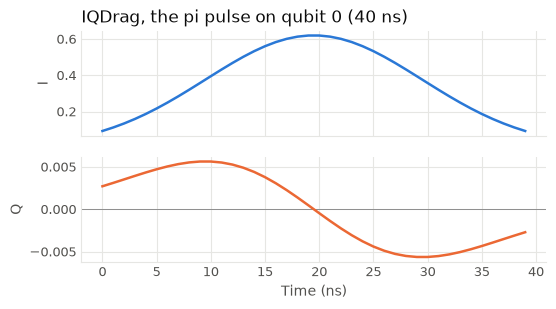

I and Q are shapes: Gaussian | GaussianDragCorrection
peak I: 0.6192 | peak |Q|: 0.0056
IQZero leaves Q silent: 0.0


In [18]:
ax_i, ax_q = pi_pulse.plot()  # an IQWaveform hands back the two panels it drew
ax_i.set_title(f"IQDrag, the pi pulse on qubit 0 ({pi_pulse.get_duration()} ns)", loc="left")
ax_q.axhline(0.0, color="grey", linewidth=0.6)
plt.show()

print("I and Q are shapes:", type(pi_pulse.get_I()).__name__, "|", type(pi_pulse.get_Q()).__name__)
print("peak I:", round(pi_pulse.get_I().peak_amplitude(), 4), "| peak |Q|:", round(pi_pulse.get_Q().peak_amplitude(), 4))
print("IQZero leaves Q silent:", IQZero(Square(amplitude=0.2, duration=2000)).get_Q().peak_amplitude())

### Structural equality

Waveforms compare and hash by structure rather than by identity, so two `Gaussian(0.5, 40, 8)` objects built in different cells are the same waveform. The type has to match exactly, so a subclass never equals its base.

Two things in this notebook rest on it. It lets a program count the distinct envelopes it really plays, the number printed in section 1.4, and it is the guarantee the file round trip is checked against in section 1.5. One trap comes with it. `QProgram` itself defines no `__eq__`, so every comparison below reads `a.body == b.body` and never `a == b`.

In [19]:
print("same shape:       ", Gaussian(0.5, 40, 8) == Gaussian(0.5, 40, 8))
print("one sigma apart:  ", Gaussian(0.5, 40, 8) == Gaussian(0.5, 40, 9))
print("the pi pulse:     ", pi_pulse == IQDrag(DEVICE["q0_a_pi"], 40, 10, 0.15))
print("distinct in a set:", len({Gaussian(0.5, 40, 8), Gaussian(0.5, 40, 8), Gaussian(0.5, 40, 9)}))

same shape:        True
one sigma apart:   False
the pi pulse:      True
distinct in a set: 2


### String aliases

Look again at the `.qp` text of `drive_program`. The amplitude 0.62 is welded into it, and that number came out of a Rabi fit and moves as the chip drifts.

`play` and `measure` also accept a string alias instead of a waveform. The program then says which pulse it wants, and the numbers arrive later from `with_waveforms`, which returns a new program and leaves the original alone.

Two rules govern the substitution. It is lenient about names it does not recognise, so an alias with no entry stays a string, and `body.waveforms()` is how you ask a program what it still needs. It is strict about shapes, so the channel check from section 1.1 runs again at the bind rather than back at the `play`. Part 3 fits a real pi pulse, binds it this way, and swaps the plain dict below for a `WaveformLibrary` that resolves a name differently per bus.

In [20]:
aliased = qp.QProgram(label="drive_then_read", schema=schema)
aliased.play(q[0].drive, "pi")  # whatever a pi pulse is on this chip
aliased.sync([q[0].drive, q[0].readout])
aliased.measure(q[0].readout, "readout", "weights", fields=(MF.IQ, MF.STATE))

print(qp.dumps(aliased).split("body:")[1])  # the body only: the header holds nothing new here
print("still unbound:", sorted(name for name in aliased.body.waveforms() if isinstance(name, str)))

bound = aliased.with_waveforms({"pi": pi_pulse, "readout": readout_pulse, "weights": weights})
resolved = next(line.strip() for line in qp.dumps(bound).splitlines() if line.strip().startswith("play"))
print("after binding:", resolved)
print("the original: play", aliased.body.elements[0].bus, aliased.body.elements[0].waveform)

try:
    aliased.with_waveforms({"pi": Gaussian(amplitude=0.62, duration=40, sigma=10)})
except qp.ValidationError as exc:
    print("\nchecked at the bind, not at the play:", exc)


  play q[0].drive "pi"
  sync q[0].drive q[0].readout
  measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state", "iq"]

still unbound: ['pi', 'readout', 'weights']
after binding: play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
the original: play q0/drive pi

checked at the bind, not at the play: Bus 'q0/drive' is an IQ channel but received a single-channel Waveform (Gaussian). Use an IQWaveform (e.g. IQPair, IQDrag) instead.


## 1.4 The program is a tree

Binding a waveform produced a new program rather than mutating the old one, a hint about what a program is underneath. Every node in the tree is one of two things. Operations are the leaves, `Play`, `Measure`, `Wait`, `Sync`, and the rest of the table in section 1.2. Blocks are the containers, `Block` here, `Sweep`, `Average`, and `Parallel` in Part 2, and `Conditional` in Part 4.

`program.body` is the root `Block`, and `body.elements` is a plain Python list of its immediate children in the order you wrote them, the same list you indexed twice already. `drive_program` has three top-level children, because the five preparation statements live inside the `block()`.

In [21]:
print("top-level elements:", len(drive_program.body.elements))
for index, node in enumerate(drive_program.body.elements):
    print(f"  [{index}] {type(node).__name__:<8} buses={sorted(node.buses())}")

top-level elements: 3
  [0] Block    buses=['q0/drive']
  [1] Sync     buses=['q0/drive', 'q0/readout']
  [2] Measure  buses=['q0/readout']


`walk()` is the same tree in pre-order, the root `body` block first, then the `block()` you opened, then everything inside it at any depth. An operation's own `walk()` yields just that operation, so one uniform loop runs from any node and you never write the recursion yourself.

Keeping a program as data means you can compute things about a sequence before anything runs. The cell after next reads how many nanoseconds this program books on the drive line straight off the tree, the kind of question a compiler asks and you can now ask too.

In [22]:
for node in drive_program.body.walk():
    print(" ", type(node).__name__)

  Block
  Block
  SetFrequency
  SetGain
  ResetPhase
  Play
  Wait
  Sync
  Measure


In [23]:
drive_ns = 0
for node in drive_program.body.walk():
    if isinstance(node, Play) and node.bus == q[0].drive:
        drive_ns += node.waveform.get_duration()
    elif isinstance(node, Wait) and node.bus == q[0].drive:
        drive_ns += node.duration

print("time booked on q[0].drive:", drive_ns, "ns")

time booked on q[0].drive: 44 ns


Five accessors summarise a built program, and each answers a different question. `buses` is recomputed by walking the body on every access, so it is always the truth about the tree as it stands. `waveforms()` returns the distinct set, structural equality doing the counting, so a program playing one envelope twenty times reports one. `measurement_handles()` hands them back in declaration order, and Part 2 indexes results by exactly these. `variables` stays empty until Part 2 declares one. `schema` is the one the program adopted.

In [24]:
print("buses:    ", sorted(drive_program.buses))
print("variables:", drive_program.variables, "<- nothing declared here, that is Part 2")
print("waveforms:", len(drive_program.body.waveforms()), "distinct")
print("handles:  ", [handle.name for handle in drive_program.measurement_handles()])
print("schema:   ", drive_program.schema)

buses:     ['q0/drive', 'q0/readout']
variables: [] <- nothing declared here, that is Part 2
waveforms: 3 distinct
handles:   ['q0/readout/m0']
schema:    BusSchema(q(drive: ('IQ', False), readout: ('IQ', True)))


## 1.5 The `.qp` format

You have been reading `.qp` text since the first program in section 1.1. `qp.dumps` writes it and `qp.loads` reads it back, and `qp.save` and `qp.load` are the same pair against a file.

Two properties are worth knowing before you commit one. Nothing is truncated, so a program holding an `Arbitrary` of 4000 samples writes 4000 samples and a predistorted flux pulse becomes a large file, with no compression and no reference to an external array. And `dumps` raises `qp.SerializationError` rather than emit text it cannot read back, so a file that exists is a file that parses.

The round trip is exact, and structural equality is how you check it.

In [25]:
out = Path("out")
out.mkdir(exist_ok=True)
path = out / "drive_then_read.qp"

qp.save(drive_program, path)
text = path.read_text()

reloaded = qp.load(path)
print("wrote:", path, f"({len(text.splitlines())} lines)")
print("same structure:", reloaded.body == drive_program.body)
print("same text back:", qp.dumps(reloaded) == text)

assert reloaded.body == drive_program.body  # the guarantee, spelled out
assert qp.loads(qp.dumps(drive_program)).body == drive_program.body

wrote: out/drive_then_read.qp (20 lines)
same structure: True
same text back: True


The consequence worth having is that the file is the experiment. A `.qp` sitting next to your data still loads, still carries the measurement names you indexed the results by, and depends on nothing about the notebook that built it.

`out/drive_then_read.qp` is on disk now, so retune the pi pulse the way a lab would, by opening the file and changing 0.62 to 0.31, with `str.replace` standing in for the editor.

Watch the last two loops in particular. Structural equality answers about any node in the tree rather than about a whole file alone, so comparing `body.elements` pairwise and then descending into the one child that changed localises a colleague's edit to a single operation without reading the file.

In [26]:
original_text = path.read_text()
edited_text = original_text.replace("amplitude=0.62", "amplitude=0.31")

diff = difflib.unified_diff(
    original_text.splitlines(keepends=True),
    edited_text.splitlines(keepends=True),
    "measured.qp",
    "retuned.qp",
)
print("".join(diff))

--- measured.qp
+++ retuned.qp
@@ -14,7 +14,7 @@
     set_frequency q[0].drive 4850000000.0
     set_gain q[0].drive 1.0
     reset_phase q[0].drive
-    play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
+    play q[0].drive IQDrag(amplitude=0.31, duration=40, sigma=10, beta=0.15)
     wait q[0].drive 4
   sync q[0].drive q[0].readout
   measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state", "iq"]



In [27]:
retuned = qp.loads(edited_text)
print("whole body equal?", retuned.body == drive_program.body)

for index, (before, after) in enumerate(zip(drive_program.body.elements, retuned.body.elements, strict=True)):
    print(f"  [{index}] {type(before).__name__:<8}", "same" if before == after else "CHANGED")

print("inside the changed block:")
inner = zip(drive_program.body.elements[0].elements, retuned.body.elements[0].elements, strict=True)
for index, (before, after) in enumerate(inner):
    print(f"  [0][{index}] {type(before).__name__:<13}", "same" if before == after else "CHANGED")

whole body equal? False
  [0] Block    CHANGED
  [1] Sync     same
  [2] Measure  same
inside the changed block:
  [0][0] SetFrequency  same
  [0][1] SetGain       same
  [0][2] ResetPhase    same
  [0][3] Play          CHANGED
  [0][4] Wait          same


### 🧩 Exercise 1.1

Build one program that excites qubit 0 and qubit 1 and reads both out, then make the schema catch a mistake.

1. One `QProgram` with `label="prepare_and_read_2q"` and the same `schema`.
2. For each qubit, `set_frequency` its drive bus to `DEVICE["q<i>_f01"]`, then `play` an `IQDrag` at `DEVICE["q<i>_a_pi"]` with `duration=40, sigma=10, beta=0.15`.
3. `program.sync()` with no arguments, so both readouts start from the same point in time.
4. `measure` both readout buses, using the `"readout"` and `"weights"` aliases and `fields=(MF.IQ, MF.STATE)`. Keep each handle as you make it and print the two names.
5. Print `qp.dumps(program)`.
6. Then, inside `try` / `except qp.ValidationError`, measure `q[1].drive` and print the message.

Look at the two handle names in the output. They tell you how per-bus numbering works.

In [28]:
two_qubit = qp.QProgram(label="prepare_and_read_2q", schema=schema)

for i in (0, 1):
    two_qubit.set_frequency(q[i].drive, DEVICE[f"q{i}_f01"])
    two_qubit.play(q[i].drive, IQDrag(amplitude=DEVICE[f"q{i}_a_pi"], duration=40, sigma=10, beta=0.15))
two_qubit.sync()  # every bus in the program, so the two readouts line up

handles = []
for i in (0, 1):
    handles.append(two_qubit.measure(q[i].readout, "readout", "weights", fields=(MF.IQ, MF.STATE)))

print(qp.dumps(two_qubit))
print("handles:", [handle.name for handle in handles])  # per-bus counters, so both are m0

try:
    two_qubit.measure(q[1].drive, "readout", "weights")
except qp.ValidationError as exc:
    print("\ncaught:", exc)

#!QProgram 1.0

metadata:
  label: "prepare_and_read_2q"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  set_frequency q[0].drive 4850000000.0
  play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
  set_frequency q[1].drive 5120000000.0
  play q[1].drive IQDrag(amplitude=0.55, duration=40, sigma=10, beta=0.15)
  sync
  measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state", "iq"]
  measure q[1].readout "readout" "weights" name="q1/readout/m0" fields=["state", "iq"]

handles: ['q0/readout/m0', 'q1/readout/m0']

caught: Bus 'q1/drive' does not support acquisition (acquires=False). measure() can only be called on buses with an ADC (e.g. readout buses).


## Recap

- **Buses.** Strings work, and a `BusSchema` gives you `BusRef`s that are still strings but carry `channel`, `acquires`, and a back-pointer to the schema. Those fields reject a single-channel waveform on an IQ line, a `measure` on a bus with no ADC, and a reference from a second schema.
- **Operations** append typed nodes and return `None`, apart from `measure` and `get_parameter`. You built a readout tone with an acquisition, and a pi pulse followed by a readout.
- **A measurement handle** is a name, allocated per bus, that survives a file round trip. It is how Part 2 reads data back and how Part 4 branches.
- **Waveforms are data.** `envelope()` and `get_duration()` are the contract, `area()`, `peak_amplitude()`, `spectrum()`, and `plot()` come free, and `plot()` hands back the `Axes` everything else is built on. A string alias defers the numbers, checked at the bind rather than at the `play`.
- **The program is a tree.** `body.elements` and `walk()` read it, and you took a pulse-time budget off it before anything ran.
- **`.qp` is the artifact.** `loads(dumps(p)).body == p.body`, so a diff of two files is a diff of two calibrations.

## Next

Every program in this part runs once, with no variable in it and no shots behind it. Every calibration is a loop, and Part 2 adds them, along with the results that come back.